In [1]:
print("Laptop Repair Operations Analysis")
print("Project setup successful!")

Laptop Repair Operations Analysis
Project setup successful!


In [2]:
import pandas as pd
from io import StringIO

data = """repair_id,device_type,issue_type,priority,status,technician,opened_date,completed_date
2001,Laptop,Battery,Medium,Completed,Tech A,2026-01-05,2026-01-06
2002,Laptop,Screen,High,Completed,Tech B,2026-01-06,2026-01-08
2003,Laptop,Keyboard,Low,Completed,Tech A,2026-01-07,2026-01-07
2004,Laptop,Hard Drive,High,Completed,Tech C,2026-01-08,2026-01-10
2005,Laptop,Overheating,Medium,Completed,Tech B,2026-01-09,2026-01-11
2006,Laptop,Battery,Medium,Completed,Tech C,2026-01-10,2026-01-12
2007,Laptop,Screen,High,Completed,Tech A,2026-01-12,2026-01-15
2008,Laptop,Keyboard,Low,Open,Tech B,2026-01-13,
2009,Laptop,Hard Drive,High,Completed,Tech C,2026-01-14,2026-01-16
2010,Laptop,Overheating,Medium,Completed,Tech A,2026-01-15,2026-01-17
2011,Laptop,Battery,Low,Completed,Tech B,2026-01-17,2026-01-18
2012,Laptop,Screen,High,Completed,Tech C,2026-01-18,2026-01-21
"""

df = pd.read_csv(StringIO(data))

df

,repair_id,device_type,issue_type,priority,status,technician,opened_date,completed_date
0,2001,Laptop,Battery,Medium,Completed,Tech A,2026-01-05,2026-01-06
1,2002,Laptop,Screen,High,Completed,Tech B,2026-01-06,2026-01-08
2,2003,Laptop,Keyboard,Low,Completed,Tech A,2026-01-07,2026-01-07
3,2004,Laptop,Hard Drive,High,Completed,Tech C,2026-01-08,2026-01-10
4,2005,Laptop,Overheating,Medium,Completed,Tech B,2026-01-09,2026-01-11
5,2006,Laptop,Battery,Medium,Completed,Tech C,2026-01-10,2026-01-12
6,2007,Laptop,Screen,High,Completed,Tech A,2026-01-12,2026-01-15
7,2008,Laptop,Keyboard,Low,Open,Tech B,2026-01-13,NaN
8,2009,Laptop,Hard Drive,High,Completed,Tech C,2026-01-14,2026-01-16
9,2010,Laptop,Overheating,Medium,Completed,Tech A,2026-01-15,2026-01-17


In [3]:
df["opened_date"] = pd.to_datetime(df["opened_date"])
df["completed_date"] = pd.to_datetime(df["completed_date"])

df["repair_days"] = (
    df["completed_date"] - df["opened_date"]
).dt.days

df[["repair_id", "issue_type", "status", "technician", "repair_days"]]

,repair_id,issue_type,status,technician,repair_days
0,2001,Battery,Completed,Tech A,1.0
1,2002,Screen,Completed,Tech B,2.0
2,2003,Keyboard,Completed,Tech A,0.0
3,2004,Hard Drive,Completed,Tech C,2.0
4,2005,Overheating,Completed,Tech B,2.0
5,2006,Battery,Completed,Tech C,2.0
6,2007,Screen,Completed,Tech A,3.0
7,2008,Keyboard,Open,Tech B,NaN
8,2009,Hard Drive,Completed,Tech C,2.0
9,2010,Overheating,Completed,Tech A,2.0


In [4]:
completed = df[df["status"] == "Completed"]

print("Total repairs:", len(df))
print("Completed repairs:", len(completed))
print("Open repairs:", (df["status"] == "Open").sum())
print(f"Average repair time: {completed['repair_days'].mean():.2f} days")

print("\nRepairs by issue:")
print(df["issue_type"].value_counts())

print("\nRepairs by technician:")
print(df["technician"].value_counts())

Total repairs: 12
Completed repairs: 11
Open repairs: 1
Average repair time: 1.82 days

Repairs by issue:
issue_type
Battery        3
Screen         3
Keyboard       2
Hard Drive     2
Overheating    2
Name: count, dtype: int64

Repairs by technician:
technician
Tech A    4
Tech B    4
Tech C    4
Name: count, dtype: int64


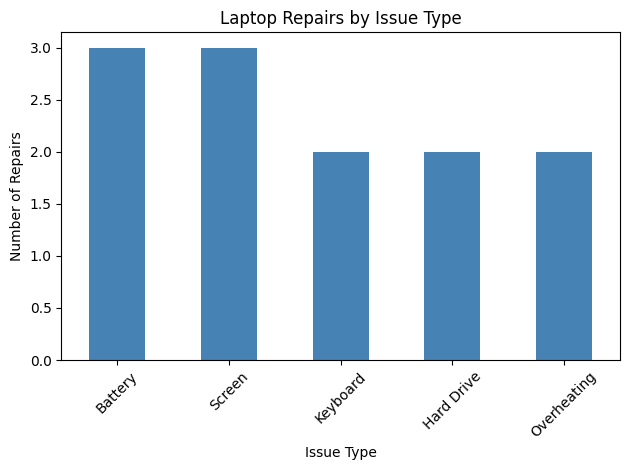

In [5]:
import matplotlib.pyplot as plt

issue_counts = df["issue_type"].value_counts()

issue_counts.plot(kind="bar", color="steelblue")

plt.title("Laptop Repairs by Issue Type")
plt.xlabel("Issue Type")
plt.ylabel("Number of Repairs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

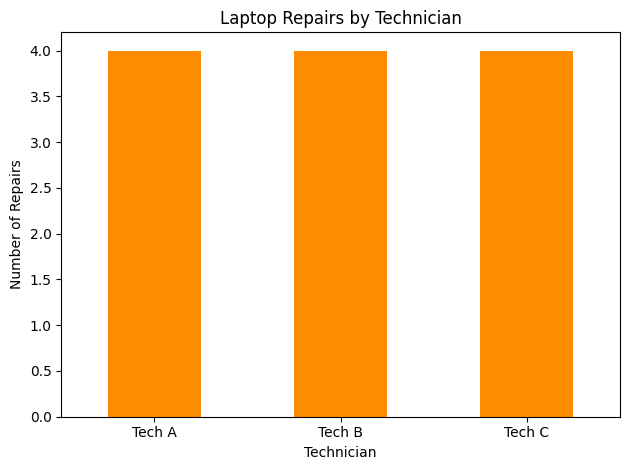

In [6]:
technician_counts = df["technician"].value_counts()

technician_counts.plot(kind="bar", color="darkorange")

plt.title("Laptop Repairs by Technician")
plt.xlabel("Technician")
plt.ylabel("Number of Repairs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()